In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import os

#import from csv that we have created the rolling stats from
pd.set_option('display.max_rows', 200)
final_X = pd.read_csv('final_nfl_rolling_stats.csv')

#we choose to only use 2005 season and on, please see readme for why
final_X = final_X[final_X['season'] >=2005].copy()

final_X.head(30)

,team_home,game_id,score_home,first_downs_home,first_downs_from_passing_home,first_downs_from_rushing_home,first_downs_from_penalty_home,third_down_comp_home,third_down_att_home,fourth_down_comp_home,...,redzone_att_away,fumbles_away,interceptions_away,def_st_td_away,possession_away,points_allowed_away,yards_allowed_away,week,season,home_win
720,49ers,842,15.500000,10.000000,8.500000,1.000000,0.500000,2.000000,9.500000,0.000000,...,3.000000,0.500000,0.000000,0.000000,NaN,19.000000,318.500000,3.0,2005,0.0
721,49ers,869,19.000000,11.750000,8.750000,2.500000,0.500000,3.500000,10.750000,0.000000,...,2.500000,0.000000,0.500000,0.500000,NaN,6.500000,320.000000,5.0,2005,0.0
722,49ers,913,16.000000,11.333333,7.000000,3.166667,1.166667,3.333333,11.500000,0.166667,...,2.500000,0.333333,1.166667,0.333333,NaN,12.000000,233.333333,8.0,2005,1.0
723,49ers,925,15.857143,11.000000,6.142857,3.714286,1.142857,3.142857,12.142857,0.142857,...,4.428571,0.857143,0.714286,0.285714,NaN,19.571429,370.857143,9.0,2005,0.0
724,49ers,955,14.000000,10.555556,5.111111,3.888889,1.555556,3.000000,12.777778,0.222222,...,4.111111,0.555556,0.777778,0.000000,NaN,18.000000,313.555556,11.0,2005,0.0
725,49ers,988,15.727273,11.545455,6.181818,3.909091,1.454545,3.181818,13.000000,0.454545,...,2.909091,0.909091,1.272727,0.363636,NaN,26.545455,328.909091,13.0,2005,0.0
726,49ers,1052,14.600000,11.466667,5.933333,4.066667,1.466667,2.800000,12.333333,0.333333,...,2.266667,0.733333,0.733333,0.133333,NaN,27.400000,366.666667,17.0,2005,1.0
727,Bears,823,7.000000,11.000000,9.000000,2.000000,0.000000,6.000000,13.000000,0.000000,...,3.000000,0.000000,0.000000,0.000000,NaN,3.000000,216.000000,2.0,2005,1.0
728,Bears,840,22.500000,14.500000,7.000000,7.500000,0.000000,7.000000,14.000000,0.000000,...,6.000000,0.500000,1.000000,0.000000,NaN,10.500000,338.500000,3.0,2005,0.0
729,Bears,882,15.500000,15.250000,7.500000,7.000000,0.750000,5.500000,14.000000,0.500000,...,2.750000,1.250000,2.500000,0.500000,NaN,26.750000,378.250000,6.0,2005,1.0


In [2]:

#split into training data and testing data (2024 only for testing, all other seasons for training) 
train = final_X[final_X['season'] < 2024]
test = final_X[final_X['season'] == 2024]

#drop things that we do not want like what we are trying to predict, and we are not going to OHE teams and week should not really matter
X_train = train.drop(columns=['home_win', 'game_id', 'team_home', 'team_away', 'week'])
X_test = test.drop(columns=['home_win', 'game_id', 'team_home', 'team_away', 'week'])

#get win col
y_train = train['home_win']
y_test = test['home_win']


In [3]:
#very first basic model, not looking for anything spectacular, just that we are better than always picking home team (which is 57% historical win rate)
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=300,
    max_depth=10,
    learning_rate=0.12,
    subsample=.6,
    colsample_bytree=.8
)
#fit model
model.fit(X_train, y_train)

# Evaluate our predictions
y_pred_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba > 0.4).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.59765625
ROC AUC: 0.5874113041350624


First model seems to be better than just straight up picking the home team every single time (57% accuracy historically). This is an alright start but I am sure that we can squeeze a whole lot more out of the model with feature tweaking and other tools that we have.

                          feature  importance
0                      score_home    0.024343
29                     score_away    0.023152
27            points_allowed_home    0.022334
40                     yards_away    0.020761
1                first_downs_home    0.020525
56            points_allowed_away    0.020144
16               sacks_yards_home    0.020029
28             yards_allowed_home    0.019816
50              redzone_comp_away    0.019781
44                 sacks_num_away    0.019585
13                  pass_att_home    0.019581
21              redzone_comp_home    0.019420
24             interceptions_home    0.018813
43                pass_yards_away    0.018755
32  first_downs_from_rushing_away    0.018571
37           fourth_down_att_away    0.018519
3   first_downs_from_rushing_home    0.018481
6             third_down_att_home    0.018404
11                     yards_home    0.018361
5            third_down_comp_home    0.018274


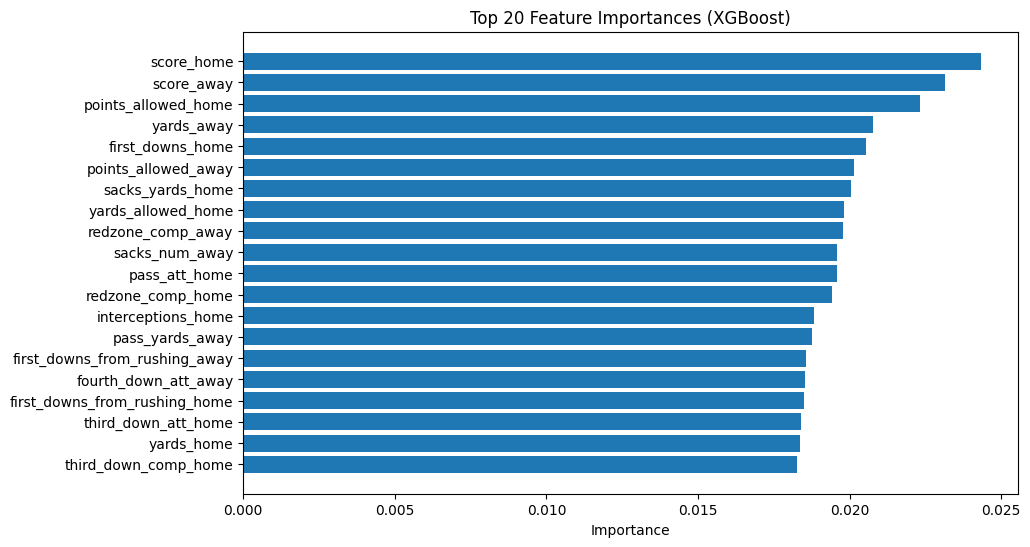

In [4]:
feature_names = X_train.columns
#Lets model what most important features are

importances = model.feature_importances_

#throw into a df for quick sorting
feat_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_importances.head(20))  # top 20 features

# Plot our importances of our first model
plt.figure(figsize=(10,6))
plt.barh(feat_importances['feature'][:20], feat_importances['importance'][:20])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

Seems as though the rolling avg points scored by both home and away teams have the highest importance which is surely to be expected. At the end of the day whoever has scored the most points should win. Probably going to want to start cutting down the number of features that we are including as they are confounding.

In [5]:
#select home and away cols
home_cols = [c for c in final_X.columns if c.endswith("_home")]
away_cols = [c for c in final_X.columns if c.endswith("_away")]

#drop the team cols as we don't want to find the diff of them, we only want numeric cols
home_cols.remove('team_home')
away_cols.remove('team_away')

#sort to make sure both are in same order
home_cols = sorted(home_cols)
away_cols = sorted(away_cols)

#we are going to look at the difference in the two teams per feature in use for upcoming models, calculate it by taking the home team stat - the away team stat
for h, a in zip(home_cols, away_cols):
    base = h.replace("_home", "")
    diff_col = f"{base}_diff"
    final_X[diff_col] = final_X[h] - final_X[a]

#keep only the cols that are the difference cols and identifiers like week, season and ofc our y in home_win 
diff_cols = [c for c in final_X.columns if c.endswith("_diff")]
X2 = final_X[diff_cols + ['week', 'season', 'home_win']]

#we are now going to utilize 2 seasons for testing to give us even more testing data to utilize and evaluate models with
train = X2[X2['season'] < 2023]
test = X2[X2['season'] >= 2023]

#drop target col and week as we don't want to use those
X_train = train.drop(columns=['home_win', 'week'])
X_test = test.drop(columns=['home_win', 'week'])

#pull out the target col
y_train = train['home_win']
y_test = test['home_win']


In [6]:
#Second Model is focused on using these diff features rather than them individually
model2 = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=300,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.88
)


#fit model with new diff features
model2.fit(X_train, y_train)

# Evaluate model for predictions
y_pred_proba = model2.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba > 0.51).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.623046875
ROC AUC: 0.619448674758103


We see a noticeable improvement with this model. Up about 3.5% accuracy when compared to the individual team stat features found in model 1. Lets keep going and see how good we can get

                          feature  importance
24                     score_diff    0.137047
28                     yards_diff    0.062366
16            points_allowed_diff    0.055301
22                 sacks_num_diff    0.044679
19              redzone_comp_diff    0.040644
23               sacks_yards_diff    0.037335
5                first_downs_diff    0.035518
2   first_downs_from_passing_diff    0.032742
9              interceptions_diff    0.032495
29                         season    0.029376
12                pass_yards_diff    0.029288
10                  pass_att_diff    0.029210
27             yards_allowed_diff    0.029032
26           third_down_comp_diff    0.028936
25            third_down_att_diff    0.028428
1                     drives_diff    0.028195
14                 pen_yards_diff    0.027257
13                   pen_num_diff    0.027053
18               redzone_att_diff    0.027050
11                 pass_comp_diff    0.026599


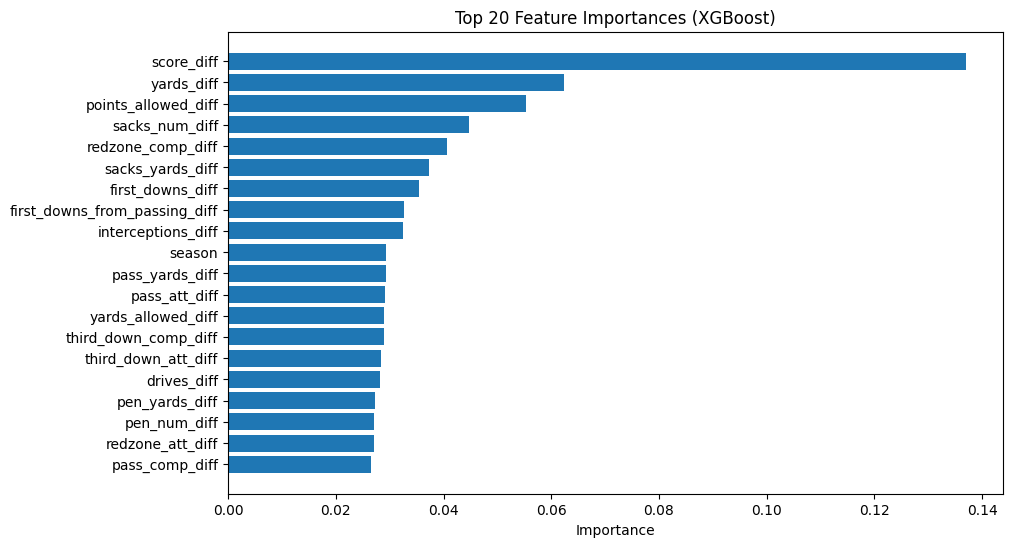

In [7]:
#grab feature names for figuring out what cols are most important
feature_names = X_train.columns


importances = model2.feature_importances_

#throw into df for quick and easy sorting and ploting
feat_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_importances.head(20))  # top 20 features

# Plot the top 20 features for model 2
plt.figure(figsize=(10,6))
plt.barh(feat_importances['feature'][:20], feat_importances['importance'][:20])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

Again here to note that the score_diff feature is still by far and away the most important. Still makes sense and still going to want to eliminate some features that could be actually hurting our accuracy.

In [8]:
#Model 3 is going to be focused on finding which subset of cols generate the best model
model3 = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

#I played around with a lot of different col combinations using the importance graphs above, my football knowledge and just general testing of different models and landed here
currCols = ['score_diff',
 'points_allowed_diff',
 'pass_att_diff',
 'pen_yards_diff',
 'first_downs_diff',
 'sacks_yards_diff',
 'first_downs_from_penalty_diff']

#train the model with the current cols
model3.fit(X_train[currCols], y_train)


# Evaluate
y_pred_proba = model3.predict_proba(X_test[currCols])[:,1]
y_pred = (y_pred_proba > 0.51).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.654296875
ROC AUC: 0.6474148937806697


Here we see that we have gained yet another noticeable improvement in the model. We have an accuracy of about 65.4% now while using far fewer features to get there.

                         feature  importance
0                     score_diff    0.172019
1            points_allowed_diff    0.147703
5               sacks_yards_diff    0.143846
4               first_downs_diff    0.136006
6  first_downs_from_penalty_diff    0.135356
2                  pass_att_diff    0.134389
3                 pen_yards_diff    0.130682


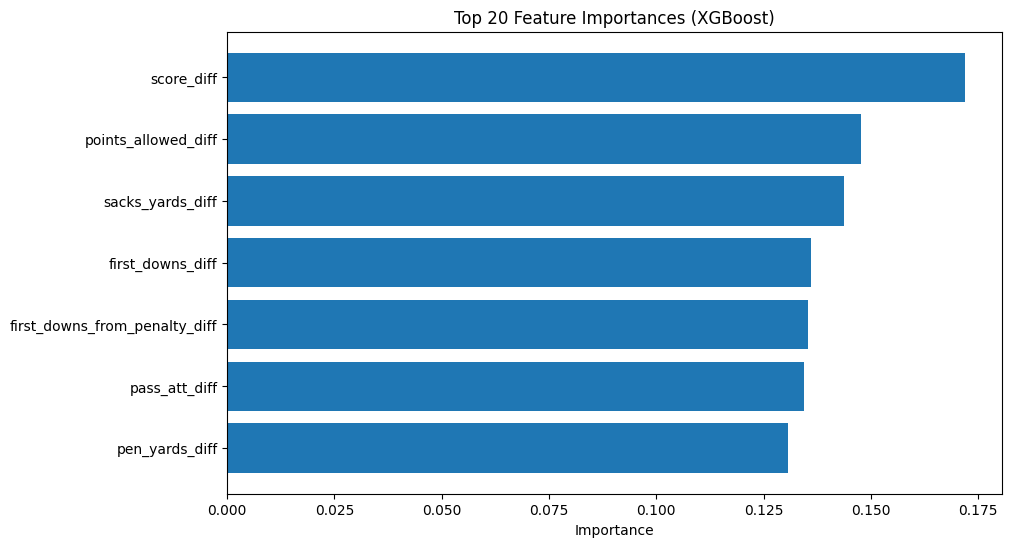

In [ ]:
#grab feature names
feature_names = currCols

#grab the importances from model 3
importances = model3.feature_importances_

#throw them into df for easy sorting and ploting
feat_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_importances.head(20))  # top 20 features

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_importances['feature'][:20], feat_importances['importance'][:20])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

I think that it is pretty clear by now that score is the #1 feature in terms of importance, then probably yards after that. I am going to make an effort to throw yards allowed and points allowed into the df and see if that helps at all.

Back after adding yards and points allowed into the df. It seems as though the points allowed helped a lot, but the yards allowed did not help whatsoever. So I for now am rolling with the following columns ['score_diff', 'yards_diff', 'redzone_att_diff', 'possession_diff', 'sacks_yards_diff', 'first_downs_diff', 'fumbles_diff', 'rush_yards_diff', 'points_allowed_diff']

In [ ]:
#set a base model4 with our given objectives and eval_metrics
model4 = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric = 'logloss',
)

#define our param grid to search through
param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [4, 5, 6, 7], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'subsample': [0.6, 0.8, 1.0], 
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}


#Grid search for finding best params
grid_search = GridSearchCV(
    estimator=model4,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=0,
    n_jobs=-1
)

#do the actual grid search
grid_search.fit(X_train[currCols], y_train)

#Best params
print("Best parameters:", grid_search.best_params_)
print("Best CV ROC AUC:", grid_search.best_score_)

#Refit on best params
best_model = grid_search.best_estimator_

#eval best model
y_pred_proba = best_model.predict_proba(X_test[currCols])[:,1]
y_pred = (y_pred_proba > 0.51).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred))

Best parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.6}
Best CV ROC AUC: 0.6714539448605009
Test Accuracy: 0.625
Test ROC AUC: 0.6187641330933592


Looks like our model is about 3 percent worse here in our test accuracy. Lets do a little more digging with some other testing and tuning.

In [ ]:
#Here we are going to try and see our accuracy across the seasons while we train on all the data other than the test season using cross validation
def seasonal_cv(df, features, target, model, start_season=2010, end_season=2024):
    results = []
    #for each season, we want to train it on all the other seasons in range, then evaluate it on the chosen season
    for test_season in range(start_season, end_season+1):
        #split into test and train data
        train_data = df[df['season'] != test_season]
        test_data  = df[df['season'] == test_season]
         
        #split into x and y data, for train and testing
        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test   = test_data[features], test_data[target]
        
        #fit model
        model.fit(X_train, y_train)
        
        #predict games
        y_proba = model.predict_proba(X_test)[:,1]
        y_pred = (y_proba > 0.51).astype(int) 
        
        #eval
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        #add to results list
        results.append({
            'season': test_season,
            'accuracy': acc,
            'roc_auc': auc
        })
        
        print(f"Season {test_season}: ACC={acc:.3f}, ROC AUC={auc:.3f}")
    #throw results in df and print the average across the seasons
    results_df = pd.DataFrame(results)
    print("\nOverall:")
    print(results_df.mean(numeric_only=True))
    return results_df

#run our seasonal cross validation with our best model from the grid search
seasonal_cv(
    df=X2, 
    features=currCols,
    target='home_win',
    model=best_model,   
    start_season=2010,
    end_season=2024
)
#run our seasonal cross validation with our model3 we thought might be better
seasonal_cv(
    df=X2, 
    features=currCols,
    target='home_win',
    model=model3,   
    start_season=2010,
    end_season=2024
)

Season 2010: ACC=0.583, ROC AUC=0.663
Season 2011: ACC=0.692, ROC AUC=0.737
Season 2012: ACC=0.617, ROC AUC=0.669
Season 2013: ACC=0.613, ROC AUC=0.660
Season 2014: ACC=0.642, ROC AUC=0.686
Season 2015: ACC=0.621, ROC AUC=0.636
Season 2016: ACC=0.617, ROC AUC=0.613
Season 2017: ACC=0.660, ROC AUC=0.692
Season 2018: ACC=0.654, ROC AUC=0.688
Season 2019: ACC=0.613, ROC AUC=0.668
Season 2020: ACC=0.662, ROC AUC=0.725
Season 2021: ACC=0.594, ROC AUC=0.616
Season 2022: ACC=0.620, ROC AUC=0.661
Season 2023: ACC=0.605, ROC AUC=0.635
Season 2024: ACC=0.648, ROC AUC=0.734

Overall:
season      2017.000000
accuracy       0.629301
roc_auc        0.672257
dtype: float64
Season 2010: ACC=0.600, ROC AUC=0.653
Season 2011: ACC=0.696, ROC AUC=0.721
Season 2012: ACC=0.625, ROC AUC=0.673
Season 2013: ACC=0.600, ROC AUC=0.633
Season 2014: ACC=0.596, ROC AUC=0.647
Season 2015: ACC=0.604, ROC AUC=0.584
Season 2016: ACC=0.571, ROC AUC=0.558
Season 2017: ACC=0.622, ROC AUC=0.670
Season 2018: ACC=0.617, ROC A

,season,accuracy,roc_auc
0,2010,0.600000,0.652917
1,2011,0.695833,0.720917
2,2012,0.625000,0.673446
3,2013,0.600000,0.633030
4,2014,0.595833,0.647337
5,2015,0.604167,0.583740
6,2016,0.570833,0.557643
7,2017,0.622407,0.669727
8,2018,0.616667,0.677024
9,2019,0.600000,0.636819


Here we can see that our grid searched model fares better in both metrics and has a much better accuracy through all the seasons that we are looking at. Therefore we are going to use that model and take a look at some insights into how our accuracy progresses across all the weeks.

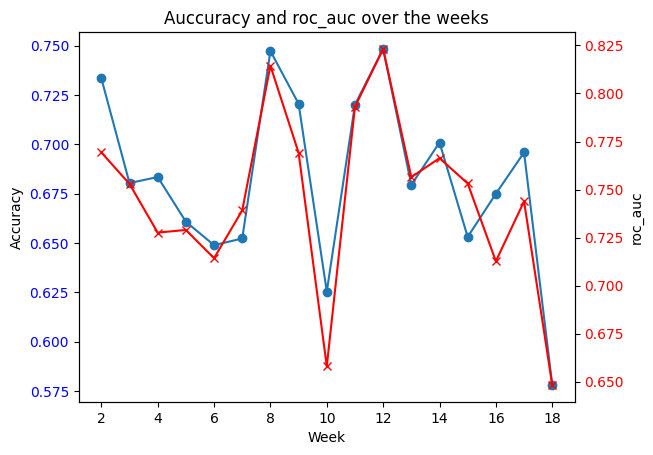

In [ ]:
def plot_week(m, features, df, target):
    #sort by weeks for x axis
    x = sorted(df["week"].unique())
    y = []

    #for each week, predict all the games in that week
    for week in x:
        y_proba = m.predict_proba(df[df['week'] == week][features])[:,1]
        y_pred = (y_proba > 0.51).astype(int) 
        y_test = df[df['week'] == week][target]
        #calculate our accuracy and roc auc score for each week
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        #add to our list for y axis
        y.append({
            'week': week,
            'accuracy': acc,
            'roc_auc': auc
        })
    #turn into df for easy plotting
    y = pd.DataFrame(y)

    #plot accuracy on left side y axis that is blue and shows each week
    fig, ax1 = plt.subplots()
    ax1.plot(x,y['accuracy'], marker="o", label = "Accuracy")
    ax1.set_xlabel("Week")
    ax1.set_ylabel('Accuracy')
    ax1.tick_params(axis="y", labelcolor="blue")
    #plot accuracy on right side y axis that is red and shows each week
    ax2 = ax1.twinx()
    ax2.plot(x, y['roc_auc'], color="red", marker="x", label="ROC AUC")
    ax2.set_ylabel('roc_auc')
    ax2.tick_params(axis="y", labelcolor="red")
    plt.title("Auccuracy and roc_auc over the weeks")
    plt.show()
    


plot_week(best_model, currCols,X2, 'home_win')

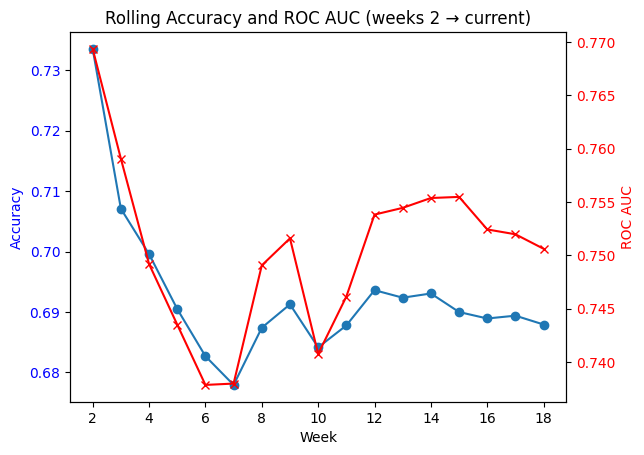

In [ ]:
def plot_week_rolling(m, features, df, target):
    x = sorted(df["week"].unique())
    y = []
    #for each week, predict all the games up to that week
    for week in x:
        # include all games from week 2 up to current week
        df_window = df[(df["week"] >= 2) & (df["week"] <= week)]

        #predict those games
        y_proba = m.predict_proba(df_window[features])[:, 1]
        y_pred = (y_proba > 0.51).astype(int)
        y_test = df_window[target]

        #find the accuracy and roc auc scores
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        #add to list for y axis
        y.append({
            "week": week,
            "accuracy": acc,
            "roc_auc": auc
        })

    #convert to df for easy plotting
    y = pd.DataFrame(y)

    #plot the accuracy on the left side y axis in blue for the rolling weeks
    fig, ax1 = plt.subplots()
    ax1.plot(x, y["accuracy"], marker="o", label="Accuracy")
    ax1.set_xlabel("Week")
    ax1.set_ylabel("Accuracy", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")

    #plot the roc auc on the right side y axis in blue for the rolling weeks
    ax2 = ax1.twinx()
    ax2.plot(x, y["roc_auc"], color="red", marker="x", label="ROC AUC")
    ax2.set_ylabel("ROC AUC", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

    plt.title("Rolling Accuracy and ROC AUC (weeks 2 → current)")
    plt.show()


plot_week_rolling(best_model, currCols,X2, 'home_win')

In [15]:
#predict all of the games that we have trained on and used to test
y_proba_full = best_model.predict_proba(X2[currCols])[:,1]
y_pred_full = (y_proba_full > 0.51).astype(int) 
y_test_full = X2['home_win']

#calculate the accuracy for all seasons of the NFL games that we have used to train and test
acc = accuracy_score(y_test_full, y_pred_full)
auc = roc_auc_score(y_test_full, y_proba_full)
print(f"Accuracy on all years with best model: {acc:.3f}")
print(f"ROC AUC on all years with best model: {auc:.3f}")

#predict the winners of games that we used to test and therefore the model has not yet seen
y_pred_proba = best_model.predict_proba(X_test[currCols])[:,1]
y_pred = (y_pred_proba > 0.51).astype(int)
y_test = test['home_win']

print("Accuracy for testing on unseen seasons in training:", accuracy_score(y_test, y_pred))
print("ROC AUC for testing on unseen seasons in training:", roc_auc_score(y_test, y_pred))

Accuracy on all years with best model: 0.688
ROC AUC on all years with best model: 0.751
Accuracy for testing on unseen seasons in training: 0.65625
ROC AUC for testing on unseen seasons in training: 0.6495608165274509


This project was a lot of fun, and I really enjoyed learning a lot about feature engineering, hyperparameter tuning, and evaluating models in a sports prediction setting. With the tuned XGBoost model, I reached about 68.8% accuracy (ROC AUC 0.75) across all years and 65.6% accuracy (ROC AUC 0.65) when testing on unseen seasons. Its still slightly off the benchmark of Vegas predictions (around 67% accuracy).
There’s still plenty of room for improvement, both in refining the features and experimenting more with parameter tuning but I had a lot of fun. The obvious application here is to try and use my model to sports bet and make money but I doubt that I will be doing that. That being said I would love to start tracking the models predictions for the upcoming 2025 NFL season. Maybe I will come back and see how it fared at the end of the year and keep track of my own predictions of who will win and see who can predict the outcome of football games better.